# 1. Front Mattter
 Project: **Wolfram Beta**

 Author: Liam Edson

 GitHub Repo: https://github.com/lledson425/Machine-Learning-Final-Project

## 2. Abstract
This project explores algebraic problem solving using next-token prediction models. The three models considered are a simple feed-forward next-token prediction model, a feed-forward model with multi-headed attention, and a full transformer model. The training data consisted of synthetically generated algebraic solutions broken into correct series of correct steps to the solutin. Although all three models struggled to learn the underlying rules of algebra, they were largely successful at learning algebraic syntax and producing mathematically valid looking output.


# 3. Introduction
A major goal for modern LLM and next token prediction models is go beyond producing valid langauge and actually reason about the prompts given. Algebriac problem solving is a clear demonstration of a models ability to reason. A model solving algebra problems both needs to learn both syntatic and mathmatical rules of algebra. This is problem that has in large part been already solved by the numerous LLMs which are very equipped to solve algebra.

This problem in large part has been solved through symbolic AI often called "Good Old-Fashioned AI" which relies on hardcoded rules that mimic human thought. Geddes, Czapor, and Labahn’s Algorithms for Computer Algebra provides important background for understanding how algebraic problem solving has traditionally been handled by computers. This book published in 1992 outlines hundreds of different pseudocode algorithtms compiled togethor that can symbolically solve algebra problems. This hardcoded problem solving is the foundation that programs like MAPLE and MATHEMATICA are built on.

*Geddes, K. O., Czapor, S. R., & Labahn, G. (1992). Algorithms for Computer Algebra. Kluwer Academic Publishers.*

Looking at literature for attempts at this problem before mine a very directly related source is Lample and Charton’s paper, Deep Learning for Symbolic Mathematics. Lample and Charton attempt to perform nealry an identical task to this project however, on more complex problems. They attempt to use a seq2seq  Transformer model to solve symbolic integration as well as symbolic solving of ODEs. Lample and Charton use a very clever technique of building the mathmatical dataset with a tree representation. They were largely sucessful in their task building models that generated correct solutions on par or better than Mathmatica.

Lample, G., & Charton, F. (2019). Deep learning for symbolic mathematics. arXiv. https://arxiv.org/abs/1912.01412


Mathmatics remains a consistently difficult task for models to reason about. Beyond strict syntatic algebra  recent comparative work on neural math problem solvers notes that many systems have been developed for solving math word problems, but that performance varies significantly depending on architecture, dataset, and problem type. This is important because it shows that mathematical reasoning remains a challenging  machine learning problem.

He, B., Yu, X., Huang, L., Meng, H., Liang, G., & Chen, S. (2024). Comparative study of typical neural solvers in solving math word problems. Complex & Intelligent Systems, 10, 5805–5830. https://doi.org/10.1007/s40747-024-01454-8

I will test three increasingly complex models in order to determine whether or not they can learn the syntax and rules of algebra.


# 4. Values Statement

The potential user of my specific project is likely no one but me. The potential users of advanced next-token prediction models capable of reasoning, at least in the narrative of AI companies, are every person on the planet. The infatuation with LLMs and reasoning models affects an untold number of people, benefiting some in productivity, creativity, etc., and harming others by stunting learning, using electricity and water, etc.

I chose to work on this project because I think text generation is a very interesting problem to try to tackle. I am also a very frequent user of Wolfram Alpha, so this was just a concept I was generally interested in. My specific implementation will have likely no impact on the world. It serves as a small experiment to uncover the limitations of model architectures we studied in class with a problem I found interesting.


**Now let us look at some code**

In [1]:
!git clone https://github.com/lledson425/Machine-Learning-Final-Project.git
%cd Machine-Learning-Final-Project

Cloning into 'Machine-Learning-Final-Project'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 155 (delta 60), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 2.91 MiB | 14.25 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/Machine-Learning-Final-Project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
import pickle
import random
from torch.utils.data import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


from src.alg_tokenizer import AlgebraTokenizer
from src.data_set import TargetOnlyNextTokenDataset
from src.seuss_model import SeussModel
from src.math_model1 import MathModel1
from src.math_model2 import MathModel2
from src.model_eval import ModelEvaluator

# 5. Data
Data for this project was synthetically generated using a Python script that relied on NumPy for formatting the output text. The output of this script was a CSV containing factorable quadratic problems and linear problems with target next-step solutions.


**Load The Data:**

In [3]:
train_url = "https://raw.githubusercontent.com/lledson425/Machine-Learning-Final-Project/main/data/train_algebra_dataset.csv"
train_df = pd.read_csv(train_url)
test_url = "https://raw.githubusercontent.com/lledson425/Machine-Learning-Final-Project/main/data/test_algebra_dataset.csv"
test_df = pd.read_csv(test_url)

train_df.iloc[20:26]

,type,input_text,target_text
20,quadratic,x^2 - 2x - 35 = 0 ->,(x + 5)(x - 7) = 0
21,linear,3x + 9 = 33 ->,3x = 24
22,linear,3x = 24 ->,x= 8
23,linear,9x + 3 = 93 ->,9x = 90
24,linear,9x = 90 ->,x= 10
25,quadratic,x^2 - 3x - 18 = 0 ->,(x + 3)(x - 6) = 0


This data as previously described is a csv of strings with input texts and the correct next step in solving the algebriac problem.

As part of the data preperation I built a custom tokenization and encoding scheme which works like this.

In [4]:
example = "x(x - 9) = 0 ->"

tokenizer = AlgebraTokenizer()
split = tokenizer.split(example)
vocab, token_to_id, id_to_token = tokenizer.build_vocab([split])
tokens = tokenizer.encode(split)
decoded = tokenizer.decode(tokens)
print("Original:", example)
print("Split:", split)
print("Vocab:", vocab)
print("Encoded:", tokens)
print("Decoded:", decoded)


Original: x(x - 9) = 0 ->
Split: ['x', '*', '(', 'x', '-', '9', ')', '=', '0', '->']
Vocab: ['<PAD>', '<SOS>', '<EOS>', '<SEP>', '<UNK>', 'x', '*', '(', '-', '9', ')', '=', '0', '->']
Encoded: [5, 6, 7, 5, 8, 9, 10, 11, 12, 13]
Decoded: ['x', '*', '(', 'x', '-', '9', ')', '=', '0', '->']


Now let's look at the attributes of the full training data set

In [5]:
full_token_lists = []

for inp, tgt in zip(train_df["input_text"], train_df["target_text"]):
    input_tokens = tokenizer.split(inp)
    target_tokens = tokenizer.split(tgt)

    full_tokens = ["<SOS>"] + input_tokens + ["<SEP>"] + target_tokens + ["<EOS>"]
    full_token_lists.append(full_tokens)

# build vocab
vocab, token_to_id, id_to_token = tokenizer.build_vocab(full_token_lists)

print("Number of equations:", len(full_token_lists))
print("Vocabulary size:", len(vocab))
print("First split example:", full_token_lists[0])

Number of equations: 37541
Vocabulary size: 115
First split example: ['<SOS>', '7', '*', 'x', '-', '8', '=', '-', '29', '->', '<SEP>', '7', '*', 'x', '=', '-', '21', '<EOS>']


Examining the most common tokens might give some insight into model behavoir later.

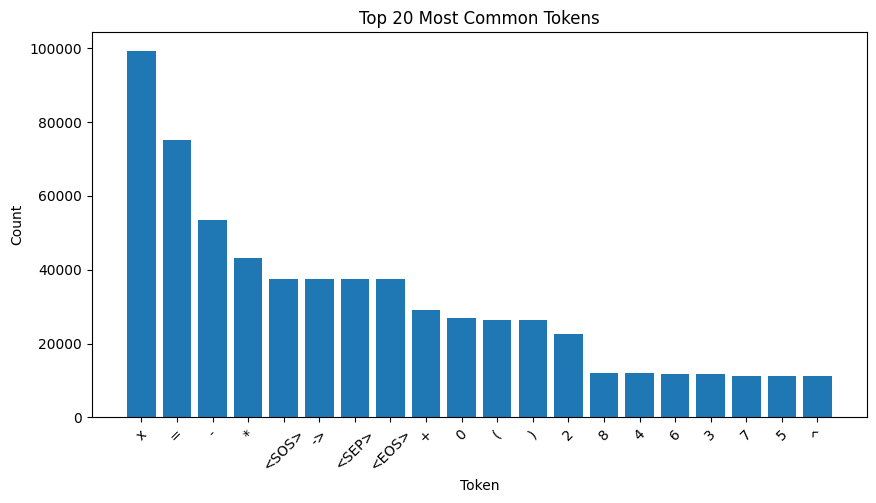

In [6]:
all_tokens = []
for token_list in full_token_lists:
    all_tokens.extend(token_list)

token_counts = Counter(all_tokens)
top_tokens = token_counts.most_common(20)
tokens, counts = zip(*top_tokens)

plt.figure(figsize=(10, 5))
plt.bar(tokens, counts)
plt.xticks(rotation=45)
plt.xlabel("Token")
plt.ylabel("Count")
plt.title("Top 20 Most Common Tokens")
plt.show()

Of all non variable tokens there is a heavy skew twoards equal signs and operators.

# 6. My Approach


The first thing I needed was features and targets from the csv. I built a dataset class that takes in a fixed context window of tokens as the features and returns a single token as the target. This is very similar to the class that we used in class It uses left padding when the input is smaller than the context window. It works like this:

In [7]:
context_length = 12
dataset = TargetOnlyNextTokenDataset(
    full_token_lists=full_token_lists,
    tokenizer=tokenizer,
    context_length=context_length
)

print("Number of training examples:", len(dataset))

for i in range(6):
    x, y = dataset[i]

    context_tokens = [id_to_token[int(idx)] for idx in x]
    target_token = id_to_token[int(y)]

    print("\nExample", i)
    print("Context IDs: ", x.tolist())
    print("Context tokens:", context_tokens)
    print("Target ID:   ", int(y))
    print("Target token:", target_token)

Number of training examples: 292755

Example 0
Context IDs:  [0, 1, 5, 6, 7, 8, 9, 10, 8, 11, 12, 3]
Context tokens: ['<PAD>', '<SOS>', '7', '*', 'x', '-', '8', '=', '-', '29', '->', '<SEP>']
Target ID:    5
Target token: 7

Example 1
Context IDs:  [1, 5, 6, 7, 8, 9, 10, 8, 11, 12, 3, 5]
Context tokens: ['<SOS>', '7', '*', 'x', '-', '8', '=', '-', '29', '->', '<SEP>', '7']
Target ID:    6
Target token: *

Example 2
Context IDs:  [5, 6, 7, 8, 9, 10, 8, 11, 12, 3, 5, 6]
Context tokens: ['7', '*', 'x', '-', '8', '=', '-', '29', '->', '<SEP>', '7', '*']
Target ID:    7
Target token: x

Example 3
Context IDs:  [6, 7, 8, 9, 10, 8, 11, 12, 3, 5, 6, 7]
Context tokens: ['*', 'x', '-', '8', '=', '-', '29', '->', '<SEP>', '7', '*', 'x']
Target ID:    10
Target token: =

Example 4
Context IDs:  [7, 8, 9, 10, 8, 11, 12, 3, 5, 6, 7, 10]
Context tokens: ['x', '-', '8', '=', '-', '29', '->', '<SEP>', '7', '*', 'x', '=']
Target ID:    8
Target token: -

Example 5
Context IDs:  [8, 9, 10, 8, 11, 12, 3, 

I trained three models on this dataset:

* The first model is the **SeussModel**. This is the exact model we looked at in class, but without the pretrained embedding. It is just a simple feed-forward model.
* The second model is **MathModel1**. This is almost exactly the SeussModel, but with multi-headed attention and normalization to give the model some ability to learn long-range dependencies.
* The final model is **MathModel2**. This is a full transformer-block model implemented using the built-in Torch transformers. Overall, it is very similar to GPT-2, but without a causal mask.

I built these models as they were ideas we had looked at in class with increasing complexity. All models were trained in a collab notebook using the collab pro G4 or H1000 gpus. Lets take a look at how they each do

We generate tokens just like we did in class stopping when we reach the end of sequence token

In [8]:
def generate_solution(
    model,
    input_text,
    token_to_id,
    id_to_token,
    max_new_tokens=30,
    temperature=.7,
    greedy=True,
):
    model.eval()

    tokens = tokenizer.split(input_text)

    for step in range(max_new_tokens):
        context_tokens = tokens[-model.context_length:]

        while len(context_tokens) < model.context_length:
            context_tokens = ["<PAD>"] + context_tokens

        context_ids = tokenizer.encode(context_tokens)
        x = torch.tensor([context_ids], dtype=torch.long).to(device)

        with torch.no_grad():
            preds = model(x)[0]

            prev_token = tokens[-1]

            if step < 3: # model was very likely to predict this token and give no output
              preds[token_to_id["<EOS>"]] = -1e9

            if greedy:
                next_id = torch.argmax(preds).item()
            else:
                preds = preds / temperature
                probs = torch.softmax(preds, dim=-1)
                next_id = torch.multinomial(probs, 1).item()

        next_token = id_to_token[next_id]

        if next_token == "<EOS>":
            break

        tokens.append(next_token)

    return tokens

Small helper to turn tokens back into single string

In [9]:
def tokens_to_string(tokens):
    filtered = [t for t in tokens if t not in {"<PAD>", "<SOS>", "<EOS>"}]
    return "".join(filtered)

Let's look at some output randomly selected generated solutionfrom our test_df

In [10]:
def generate_random_examples(
    model,
    df,
    input_col,
    token_to_id,
    id_to_token,
    num_examples=5,
    max_new_tokens=30,
    temperature=2,
    greedy=True
):
    prompts = random.sample(list(df[input_col]), num_examples)

    for i, prompt in enumerate(prompts, start=1):
        generated = generate_solution(
            model,
            prompt,
            token_to_id,
            id_to_token,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            greedy=greedy
        )

        print(f"Example {i}")
        print("Input:     ", prompt)
        print("Generated: ", tokens_to_string(generated))
        print()

First **SeussModel**

In [11]:
sm_model = pickle.load(open("/content/Machine-Learning-Final-Project/models/model_sm.pkl", "rb"))

In [12]:
generate_random_examples(
    model=sm_model,
    df=test_df,
    input_col="input_text",
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    num_examples=5
)

Example 1
Input:      2x - 9 = -17 ->
Generated:  2*x-9=-17->9x=-9

Example 2
Input:      8x = -32 ->
Generated:  8*x=-32->xx=-4

Example 3
Input:      x + 9 = 6 ->
Generated:  x+9=6->x=3

Example 4
Input:      x - 4 = -8 ->
Generated:  x-4=-8->x=8

Example 5
Input:      8x - 8 = -40 ->
Generated:  8*x-8=-40->78*x=-32



Next lets look at **MathModel1**

In [13]:
mm1_model = pickle.load(open("/content/Machine-Learning-Final-Project/models/model_mm1_ver2.pkl", "rb"))

In [14]:
generate_random_examples(
    model=mm1_model,
    df=test_df,
    input_col="input_text",
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    num_examples=5
)

Example 1
Input:      x^2 + x - 12 = 0 ->
Generated:  x^2+x-12=0->x(x+4)(x-3)=0

Example 2
Input:      3x = 30 ->
Generated:  3*x=30->xx=10

Example 3
Input:      3x = 27 ->
Generated:  3*x=27->xx=3

Example 4
Input:      x^2 - 16x + 63 = 0 ->
Generated:  x^2-16*x+63=0->x(x+7)(x-8)=0

Example 5
Input:      2x = -2 ->
Generated:  2*x=-2->xx=-1



Finally **MathModel2**

In [15]:
mm2_model = pickle.load(open("/content/Machine-Learning-Final-Project/models/model_mm2.pkl", "rb"))

In [16]:
generate_random_examples(
    model=mm2_model,
    df=test_df,
    input_col="input_text",
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    num_examples=5
)

Example 1
Input:      8x + 7 = 79 ->
Generated:  8*x+7=79->14)=1

Example 2
Input:      x^2 + 3x - 18 = 0 ->
Generated:  x^2+3*x-18=0->2(x-3)(x-2)=0

Example 3
Input:      x^2 - 5x - 24 = 0 ->
Generated:  x^2-5*x-24=0->2(x-3)(x-2)=0

Example 4
Input:      6x = -18 ->
Generated:  6*x=-18->x=9

Example 5
Input:      7x - 3 = 25 ->
Generated:  7*x-3=25->1)=0



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


# 7. Results

Now lets do some more extensive testing and comparison. My test set is 10,000 unseeen equations. This was synthetically generated in the same way the train data set was. There was no need need to do a test train split as I can make as much data as I want. To do this testing we will evaluate if the model predictions are correct (they won't be). If the are syntatically corrrect and if they are not syntatically correct why they are wrong.

**First SeussModel:**

In [17]:
evaluator = ModelEvaluator(
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    generate_solution_fn=generate_solution,
    tokens_to_string_fn=tokens_to_string
)

results_df = evaluator.evaluate_model(
    model=sm_model,
    df=test_df,
    input_col="input_text",
    target_col="target_text",
    category_col="type",
    num_examples=10000
)

summary = evaluator.summarize_results(results_df)
error_counts = evaluator.summarize_syntax_errors(results_df)

OVERALL RESULTS
Number of examples: 10000
Syntax accuracy: 0.7142
Exact match accuracy: 0.0

RESULTS BY CATEGORY
           num_examples  syntax_accuracy  exact_match_accuracy
category                                                      
linear             6709         0.763601                   0.0
quadratic          3291         0.613491                   0.0

MOST COMMON SYNTAX ERRORS
             syntax_error  count  percent_of_errors  percent_of_total
    too_many_equals_signs   1768           0.618614            0.1768
extra_closing_parenthesis    659           0.230581            0.0659
     unclosed_parenthesis    195           0.068230            0.0195
        operator_at_start    145           0.050735            0.0145
      missing_equals_sign     53           0.018544            0.0053
          operator_at_end     36           0.012596            0.0036
          double_operator      2           0.000700            0.0002


This model does much better on linear equations than on quadratic equations. The model performed best when it had a context window of 8 tokens, which is relatively short. This made it difficult for the model to properly use parentheses, which explains why it performed relatively poorly on quadratic equations. Furthermore, this model uses the equal sign very often, which is expected given how common that character is.

**Now MathModel1**



In [18]:
evaluator = ModelEvaluator(
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    generate_solution_fn=generate_solution,
    tokens_to_string_fn=tokens_to_string
)

results_df = evaluator.evaluate_model(
    model=mm1_model,
    df=test_df,
    input_col="input_text",
    target_col="target_text",
    category_col="type",
    num_examples=10000
)

summary = evaluator.summarize_results(results_df)
error_counts = evaluator.summarize_syntax_errors(results_df)

OVERALL RESULTS
Number of examples: 10000
Syntax accuracy: 0.797
Exact match accuracy: 0.0

RESULTS BY CATEGORY
           num_examples  syntax_accuracy  exact_match_accuracy
category                                                      
linear             6709         0.749590                   0.0
quadratic          3291         0.893649                   0.0

MOST COMMON SYNTAX ERRORS
             syntax_error  count  percent_of_errors  percent_of_total
    too_many_equals_signs    566           0.278818            0.0566
      missing_equals_sign    526           0.259113            0.0526
     unclosed_parenthesis    394           0.194089            0.0394
        operator_at_start    260           0.128079            0.0260
extra_closing_parenthesis    166           0.081773            0.0166
          double_operator     87           0.042857            0.0087
    bad_operator_sequence     22           0.010837            0.0022
          operator_at_end      9           0.0044

This model performs much better than the SeussModel, with an overall syntactic accuracy of 0.797. The addition of the attention mechanism appears to help the model handle longer-range relationships between tokens, especially with parentheses. This allowed the model to perform better on quadratic equations with a syntatic accuracy of 0.893649, where correct use of parentheses is much more important. However, the model still does not have any exact matches and has the issue of overusing the equal sign.

**Finally MathModel2** (this takes a few minutes to run over 10,000 examples with free google gpus)

In [19]:
evaluator = ModelEvaluator(
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    generate_solution_fn=generate_solution,
    tokens_to_string_fn=tokens_to_string
)

results_df = evaluator.evaluate_model(
    model=mm2_model,
    df=test_df,
    input_col="input_text",
    target_col="target_text",
    category_col="type",
    num_examples=10000
)

summary = evaluator.summarize_results(results_df)
error_counts = evaluator.summarize_syntax_errors(results_df)

OVERALL RESULTS
Number of examples: 10000
Syntax accuracy: 0.717
Exact match accuracy: 0.0

RESULTS BY CATEGORY
           num_examples  syntax_accuracy  exact_match_accuracy
category                                                      
linear             6709         0.672977                   0.0
quadratic          3291         0.806746                   0.0

MOST COMMON SYNTAX ERRORS
             syntax_error  count  percent_of_errors  percent_of_total
extra_closing_parenthesis   1585           0.560071            0.1585
    too_many_equals_signs    436           0.154064            0.0436
        operator_at_start    381           0.134629            0.0381
      missing_equals_sign    367           0.129682            0.0367
     unclosed_parenthesis     31           0.010954            0.0031
          double_operator     30           0.010601            0.0030


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

This model performs worse than MathModel1, with an overall syntactic accuracy of 0.717. The transformer model performs better on quadratic equations than linear equations, with a quadratic syntax accuracy of 0.807 compared to 0.673 for linear equations. This suggests that the transformer may be better at handling longer-range structure, such as parentheses, but it still has no exact matches. I think this poor performance is symptomatic of an overly complex model for the relatively short input equations.

# 8. Concluding Discussion

Overall, this project partially worked. The models were able to learn the syntax of algebra to some extent, especially the structure of expressions, equal signs, operators, and parentheses. This shows that next-token prediction models can learn patterns in algebraic text and produce outputs that often resemble valid algebraic steps. However, the models did not successfully learn the actual mathematical rules needed to solve algebra problems. The exact match accuracy was 0.0 for the models, which shows that even when the output was syntactically valid, it was usually not the correct next algebraic step.

At the beginning of the project, the goal was to test whether increasingly complex next-token prediction models could learn both the syntax and rules of algebra, as well as to build a script to generate an algebraic dataset. The script works very well, and I am glad I got to experiment with the SymPy package. The goal of producing syntactically correct output was somewhat met, but the goal of solving algebra was not.

Compared to other work in this area, my results were much more limited. Any large language model can outperform what I produced. Lample and Charton’s work even shows that generative models may be able to outperform symbolic AI on certain tasks. With more time, resources, and compute, I might be able to get better results. Restructuring how my data was represented might also be important. I think a seq2seq RNN architecture would have been more effective than anything I tried. This problem has been solved, and with more work I likely could have gotten closer than this project did.

